# Pre-training a Mini Vision Transformer with 3,2M Parameters from Scratch

This notebook covers the complete workflow for pre-training a Vision Transformer (ViT) model from scratch, using the **CIFAR-100** dataset.
Link to ViT Paper: https://arxiv.org/pdf/2010.11929

### 📌 Model & Training Parameters
The ViT architecture and the optimization process have been set up with the following configuration:
- **Image & Patches**: Resolution of $32 \times 32$, with a patch size of $4 \times 4$.
- **ViT Dimensions**: Embedding dimension of ,  transformer encoder blocks, attention heads, and an inner MLP dimension of.
- **Training Setup**: Batch size of `128`, a base learning rate of `3e-4` (using `OneCycleLR` scheduler), a dropout rate of `0.4`, and testing up to `500` epochs (with an early stopping mechanism based on validation loss).

### 📊 Experiment Tracking
**Weights & Biases (W&B)** for tracking the experiments. It automatically logs vital metrics like the training/validation losses and accuracies during the custom training loop, which provides a detailed, interactive report for performance analysis.

Link to the report: https://api.wandb.ai/links/duongsemailforeverything-/e7up3s1h

### 👀 Visualization: Attention Rollout
To better understand what the Vision Transformer has learned, I use a technique called Attention Rollout to visualize its internal focus.
Link to the paper: https://arxiv.org/pdf/2005.00928

Because information in a ViT passes through multiple layers and attention heads, simply looking at the attention maps of a single layer doesn't give a complete picture. Attention Rollout solves this by recursively multiplying the attention weights across all layers from top to bottom, while accounting for residual connections.

This process traces the flow of information from the final classification token ([CLS]) back to the original image patches. The resulting heatmap clearly highlights the most salient regions of the input image, showing us exactly which features the model was "looking at" when it made its final prediction.

In [1]:
!pip install wandb -q
import torch
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim


import matplotlib.pyplot as plt

import wandb

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH = './data'
    SAVE_PATH = '/content/drive/MyDrive/DL'
    print("✅ Contected to Google Drive")
except(ValueError, ImportError, Exception) as e:
    print(f"❌ Error: {e}")
    print("❌ Failed to mount to Google Drive --> ✅ Use Local Path")
    DATA_PATH = "./data"
    SAVE_PATH = DATA_PATH

❌ Error: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.
❌ Failed to mount to Google Drive --> ✅ Use Local Path


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


# Log into W&B
wandb.login()

cuda


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: duongsemailforeverything (duongsemailforeverything-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
IMG_SIZE = 32
PATCH_SIZE = 4
IN_CHANNELS = 3
BATCH_SIZE = 128

# Training
LR = 3e-4
DROP_RATE = 0.4
EPOCHS = 200

# ViT
EMBED_DIM = 256
MLP_DIM = 512
ENC_NUMS = 6
MSA_NUMS = 8
CLS_NUMS = 100

In [5]:
stats = ((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))

train_transform = transforms.Compose([
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
    transforms.RandomErasing(p=0.25)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [6]:
from torch.utils.data import random_split
import copy

full_data = datasets.CIFAR100(root=DATA_PATH, train=True, download=True, transform=train_transform)

train_size = int(0.8 * len(full_data))
val_size = len(full_data) - train_size

train_subset, val_subset = random_split(full_data, [train_size, val_size])

val_subset.dataset = copy.copy(full_data)

val_subset.dataset.transform = test_transform

test_data = datasets.CIFAR100(root=DATA_PATH, train=False, download=True, transform=test_transform)

100%|██████████| 169M/169M [00:03<00:00, 48.6MB/s] 


In [7]:
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=4, pin_memory=True)

val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=4, pin_memory=True)
                            
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=4, pin_memory=True)

In [8]:
class EmbeddedPatches(nn.Module):
    def __init__(self, img_size, in_channels, embed_dim, patch_size, batch_size):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, patch_size, patch_size)
        N = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_token = nn.Parameter(torch.randn(1, N+1, embed_dim))

    def forward(self, x):
        B = x.size(0)
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.pos_token

        return x

In [9]:
class MLP(nn.Module):
    def __init__(self, in_features, out_features, drop_rate):
        super().__init__()
        self.layer1 = nn.Linear(in_features, out_features)
        self.layer2 = nn.Linear(out_features, in_features)
        self.dropout = nn.Dropout(drop_rate)

    def forward(self, x):
        x = self.layer1(x)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.dropout(x)

        return x

In [10]:
class VisionEncoder(nn.Module):
    def __init__(self, embed_dim, msa_size, mlp_dim, enc_dim, drop_rate):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, msa_size, drop_rate, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_dim, drop_rate)

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))

        return x


In [11]:
class ClassHead(nn.Module):
    """Classification MLP Head as described in the ViT paper.

    Architecture: LayerNorm -> Linear(embed_dim, mlp_dim) -> GELU -> Dropout -> Linear(mlp_dim, cls_nums)
    """
    def __init__(self, embed_dim, mlp_dim, cls_nums, drop_rate):
        super().__init__()
        self.norm   = nn.LayerNorm(embed_dim)
        self.layer1 = nn.Linear(embed_dim, mlp_dim)
        self.act    = nn.GELU()
        self.dropout = nn.Dropout(drop_rate)
        self.layer2 = nn.Linear(mlp_dim, cls_nums)

    def forward(self, x):
        x = self.norm(x)
        x = self.layer1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.layer2(x)
        return x

In [12]:
class ViT(nn.Module):
    def __init__(self, img_size, patch_size, batch_size, in_channels, embed_dim, enc_dim, msa_size, mlp_dim, cls_nums, drop_rate):
        super().__init__()
        self.embed = EmbeddedPatches(img_size, in_channels, embed_dim, patch_size, batch_size)
        self.encoder = nn.Sequential(*[
            VisionEncoder(embed_dim, msa_size, mlp_dim, enc_dim, drop_rate)
            for _ in range(enc_dim)
        ])
        self.mlp_head = ClassHead(embed_dim, mlp_dim, cls_nums, drop_rate)

    def forward(self, x):
        x = self.embed(x)
        x = self.encoder(x)
        cls_token = x[:, 0]
        x = self.mlp_head(cls_token)

        return x

In [13]:
model = ViT(IMG_SIZE, PATCH_SIZE, BATCH_SIZE, IN_CHANNELS, 
            EMBED_DIM, ENC_NUMS, MSA_NUMS, MLP_DIM, CLS_NUMS, DROP_RATE)
            
model.to(device)

ViT(
  (embed): EmbeddedPatches(
    (proj): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): VisionEncoder(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (layer1): Linear(in_features=256, out_features=512, bias=True)
        (layer2): Linear(in_features=512, out_features=256, bias=True)
        (dropout): Dropout(p=0.4, inplace=False)
      )
    )
    (1): VisionEncoder(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (layer1): Linear(in_fea

In [14]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.1,
    div_factor=10,
    final_div_factor=100
)

In [15]:
import numpy as np

class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pth', trace_func=print):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                            Default: 7
            verbose (bool): If True, prints a message for each validation loss improvement. 
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                            Default: 0
            path (str): Path for the checkpoint to be saved to.
                            Default: 'checkpoint.pth'
            trace_func (function): trace print function.
                            Default: print            
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path
        self.trace_func = trace_func
    
    def __call__(self, val_loss, model):

        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)

        elif score < self.best_score + self.delta:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True

        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            self.trace_func(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [16]:
def train(model, loader, optimizer, criterion, scheduler):
    model.train()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [17]:
def validate(model, loader, criterion):
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item() * x.size(0)

    return val_loss / len(loader.dataset)

In [18]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
    
    return correct / len(loader.dataset)

In [19]:
# Init WandB
wandb.init(
    project="vit-cifar100-scratch",
    config={
        "learning_rate": LR,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "image_size": IMG_SIZE,
        "architecture": "ViT",
        "patch_size": PATCH_SIZE,
        "embed_dim": EMBED_DIM,
        "enc_nums": ENC_NUMS,
        "msa_nums": MSA_NUMS,
        "mlp_dim": MLP_DIM,
        "drop_rate": DROP_RATE
    }
)

train_accuracies, test_accuracies = [], []
early_stopping = EarlyStopping(patience=10, path='best_model.pth')

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, scheduler)
    
    val_loss = validate(model, val_loader, criterion)
    
    test_acc = evaluate(model, test_loader)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch: {epoch}, train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, val_loss: {val_loss:.4f}, test_acc: {test_acc:.4f}")

    # Log to WandB
    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "test_acc": test_acc,
        "lr": optimizer.param_groups[0]['lr']
    })

    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print("Early Stopping")
        break

model.load_state_dict(torch.load('best_model.pth'))
print("Loaded best model")

wandb.finish()

Epoch: 0, train_loss: 4.5925, train_acc: 0.0164, val_loss: 4.4820, test_acc: 0.0352
Epoch: 1, train_loss: 4.5100, train_acc: 0.0259, val_loss: 4.3699, test_acc: 0.0465
Epoch: 2, train_loss: 4.4481, train_acc: 0.0372, val_loss: 4.2583, test_acc: 0.0642
Epoch: 3, train_loss: 4.3741, train_acc: 0.0470, val_loss: 4.1172, test_acc: 0.0895
Epoch: 4, train_loss: 4.2958, train_acc: 0.0598, val_loss: 4.0168, test_acc: 0.1061
Epoch: 5, train_loss: 4.2363, train_acc: 0.0692, val_loss: 3.9296, test_acc: 0.1207
Epoch: 6, train_loss: 4.1775, train_acc: 0.0809, val_loss: 3.8431, test_acc: 0.1440
Epoch: 7, train_loss: 4.1211, train_acc: 0.0883, val_loss: 3.7631, test_acc: 0.1569
Epoch: 8, train_loss: 4.0671, train_acc: 0.1012, val_loss: 3.6817, test_acc: 0.1761
Epoch: 9, train_loss: 4.0081, train_acc: 0.1136, val_loss: 3.5864, test_acc: 0.1928
Epoch: 10, train_loss: 3.9546, train_acc: 0.1249, val_loss: 3.5061, test_acc: 0.2140
Epoch: 11, train_loss: 3.9159, train_acc: 0.1306, val_loss: 3.4626, test_ac

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇███
lr,▂▂▄█████▇▇▇▇▆▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
test_acc,▁▁▂▂▃▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██████████████████
train_acc,▁▂▂▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇█████████████
train_loss,██▇▇▅▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,199
lr,0.0
test_acc,0.5992
train_acc,0.53705
train_loss,2.29297


In [20]:
import os

model_name = 'pre_trained_ViT_CIFAR100.pth'
save_path = os.path.join(SAVE_PATH, model_name)

torch.save(model.state_dict(), save_path)

print(f"✅ Model saved to: {save_path}")

✅ Model saved to: ./data/pre_trained_ViT_CIFAR100.pth


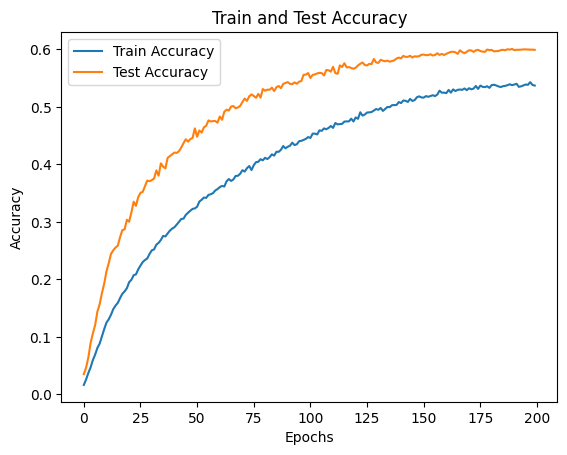

In [21]:
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.legend()
plt.title("Train and Test Accuracy")
plt.show()

## Attention Rollout (Abnar & Zuidema, 2020)

Attention Rollout is a technique to visualize how information flows from the input tokens to the embeddings in deeper layers of a Transformer. It accounts for the fact that attention in higher layers is performed on representations that have already integrated information from previous layers.

The process follows these steps:
1. **Average Heads**: For each layer, average the attention weights across all attention heads.
2. **Account for Residuals**: To model the residual (skip) connections, add an identity matrix $I$ to the attention matrix $A$: $A_{adj} = 0.5A + 0.5I$.
3. **Normalization**: Re-normalize the rows of $A_{adj}$ to ensure they sum to 1.
4. **Recursive Multiplication**: Compute the rollout at layer $L$ by multiplying the adjusted attention matrices from the input layer to the target layer:
   $Rollout(L) = A_{adj}(L) \times A_{adj}(L-1) \times \dots \times A_{adj}(1)$

The resulting matrix provides a map of the relative contribution of each input patch to the tokens at layer $L$.

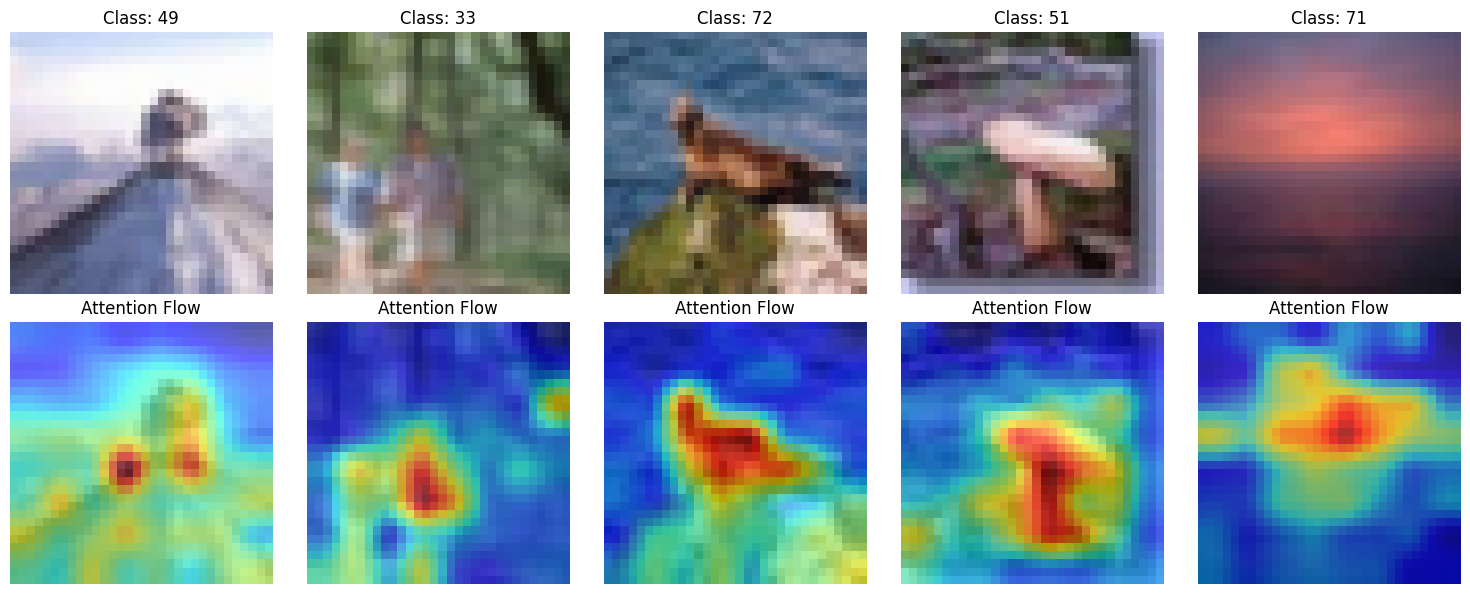

In [22]:
# --- Attention Rollout (Abnar & Zuidema, 2020) ---
import numpy as np

attention_maps = []

# Attatch "hooks" to layers
def hook_fn(module, input, output):
    attention_maps.append(output[1].detach().cpu())
# Whenever data passes through an attention layer during the forward pass,
# this hook grabs the resulting attention weights output[1] and saves them
# to the attention_maps
# .detatch() stops the tensor from being tracked for gradient calculations
# -> saving memory and stopping the graph from growing
# .cpu() moves the tensor out of the GPU memory and into standard computer
# RAM where we can safely store and plot it.

def visualize_attention_rollout(model, loader, img_size, num_images=5):
    model.eval()
    
    # 1. Attatch the visualization hook to every single layer in the ViT's encoder
    handles = []
    for layer in model.encoder:
        # Connect the hook function to the specific layer in the PyTorch model
        handle = layer.attn.register_forward_hook(hook_fn)
        # register_forward_hook(hook_fn): every time data flows forwards through
        # the att layer, it pause and run hook_fn before continuing

        handles.append(handle)
    
    # 2. Grabbe a batch of images, prepare them, and push them through the model
    # to trigger the hooks and capture the attention weights

    # 2.1: Grabbing a Batch of Data
    try:
        images, labels = next(iter(loader))
    except StopIteration:
        return
    
    # 2.2 Trucating and Moving to the GPU
    # [:num_images] slices the batch -> only keep first few images
    images = images[:num_images].to(device)
    labels = labels[:num_images]
    
    # 2.3 Clear the Memory
    global attention_maps
    attention_maps = []
    
    # 2.4 The Forward Pass to trigger the Hooks using torch.no_grad() to
    # temporary disable all gradient tracking.
    with torch.no_grad():
        output = model(images)
        


    # --- 3. Attention Rollout calculate ---
    rollout_maps = []
    
    for i in range(num_images):

        # 3.1 Extract the sequence length (the total number of tokens)
        seq_len = attention_maps[0].shape[2] 
        
        # 3.2 Create an Identity Matrix of size seq_len
        result = torch.eye(seq_len)
        # .eye() creates a 2D square tensor, where all the elements on them main
        # diagonal are 1 and all other elements are 0. 
        # tensor([[1., 0., 0., 0.],
        #         [0., 1., 0., 0.],
        #         [0., 0., 1., 0.],
        #         [0., 0., 0., 1.]]) -> .eye(4)
        
        # 3.3 Loops through every layer's attention matrix, adjust is to account
        # for residual connections and then systematically multiplies them all
        # together to track how information flows from the image all the way to
        # the final prediction
        for layer_attn in attention_maps:
            attn = layer_attn[i]
            
            # Abnar & Zuidema: Residual Connection model
            # Formula: A_new = 0.5 * A + 0.5 * Identity
            identity = torch.eye(seq_len)
            a_hat = 0.5 * attn + 0.5 * identity
            
            # Renormalize
            a_hat = a_hat / a_hat.sum(dim=-1, keepdim=True)
            
            # Matrix Multiplication: The Flow of the Information from bottom to top
            result = torch.matmul(a_hat, result)
            
        # 3.4 Isolate the specific attention weights [cls] we need to generate our visualization map
        mask = result[0, 1:]
        # mask is a simple 1D list of numbers representing only the image patches.
        # These numbers tell us extractly how much importance the model's final 
        # decision-maker (the cls token) placed on each physical patch of the image.
        
        # 3.5 Reshape the attention weights from a single flat list back into a 2D
        # gird that matches the layout of the original image patches.
        width = int(np.sqrt(len(mask)))
        mask = mask.reshape(width, width)
        
        # 3.6 Upscaling the small, low-res attention grid so that it perfectly matches
        # the size of the original image
        mask = mask.unsqueeze(0).unsqueeze(0)
        mask = F.interpolate(mask, size=(img_size, img_size), mode='bilinear', align_corners=False)
        mask = mask.squeeze().numpy()
        
        # Normalize for Plot (0 - 1)
        mask = (mask - mask.min()) / (mask.max() - mask.min())
        rollout_maps.append(mask)

    # --- 4. Plotten ---

    for handle in handles:
        handle.remove()
        
    fig, axes = plt.subplots(2, num_images, figsize=(3 * num_images, 6))
    
    for i in range(num_images):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        mean = np.array(stats[0])
        std = np.array(stats[1])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Class: {labels[i].item()}")
        axes[0, i].axis('off')
        
        axes[1, i].imshow(img)
        axes[1, i].imshow(rollout_maps[i], alpha=0.6, cmap='jet') 
        axes[1, i].set_title("Attention Flow")
        axes[1, i].axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_attention_rollout(model, test_loader, IMG_SIZE)